# Validation finale du modèle

Le jeu de test est utilisé une seule fois pour mesurer la généralisation du modèle optimisé. Il n'intervient ni dans l'apprentissage ni dans le choix des hyperparamètres.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(r"^\s*$", pd.NA, regex=True),
    errors="coerce",
)
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = X.select_dtypes(include="object").columns.tolist()

C:\Users\Hp\AppData\Local\Temp\ipykernel_5924\3589627314.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [2]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

Matrice de confusion :
[[754 281]
 [ 77 297]]

Rapport de classification :
              precision    recall  f1-score   support

    No churn       0.91      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

AUC : 0.841


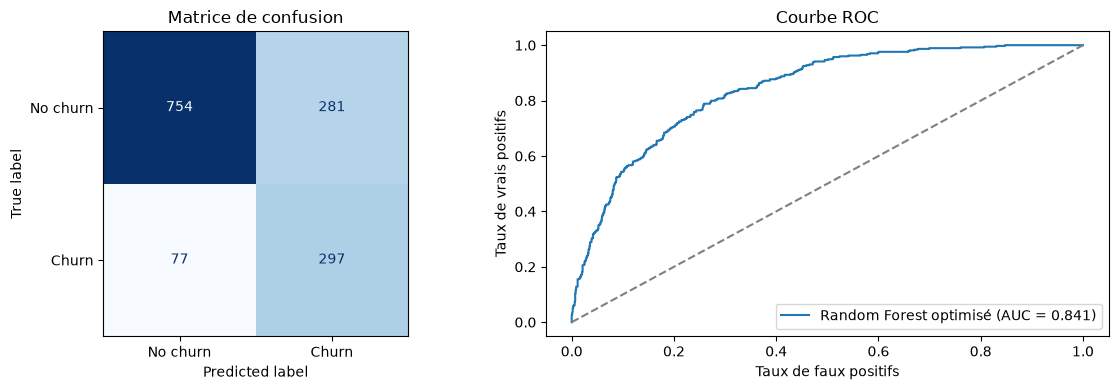

In [3]:
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

print("Matrice de confusion :")
print(cm)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
print(f"AUC : {auc_score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No churn", "Churn"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matrice de confusion")

axes[1].plot(fpr, tpr, label=f"Random Forest optimisé (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title("Courbe ROC")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].legend()
plt.tight_layout()
plt.show()

## Interprétation

Le modèle est évalué sur des données séparées et jamais utilisées pour ajuster les transformations ou choisir les hyperparamètres. Le rappel de la classe `Churn` est prioritaire, car les clients partis et non détectés représentent le risque métier principal.